In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
csv_filename1 = 'full_run_260428.csv'
df1 = pd.read_csv(csv_filename1)
df1.head()

,row,cell,Cell_Label,Z_Height_mm,RPM,Rotational_Drag,CV,R2,Trend_Slope,Second_derivative,...,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27
0,1.0,1.0,1kcP_bluesil,-65.50,45.0,0.523556,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.0,1.0,1kcP_bluesil,-65.52,45.0,0.550444,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.0,1.0,1kcP_bluesil,-65.54,45.0,0.566222,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.0,1.0,1kcP_bluesil,-65.56,45.0,0.584222,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.0,1.0,1kcP_bluesil,-65.58,45.0,0.597333,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
viscosity_mapping1 = {
'350cp': 412.07,
'1kcp': 1073.33,
'2kcp': 3345.33, 
'4kcp': 6603.00,
'5kcp': 5861.33,
'8kcp': 8946.67,
'10kcp': 9152.00,
'12.5kcp': 14576.67,
'15kcp': 19036.67,
'20kcp': 24396.67,
'25kcp': 22760.00,
'30kcp': 31903.33,
'35kcp': 63253.33,
'40kcp': 62756.67,
'45kcp': 40820.00,
'50kcp': 79653.33,
'55kcp': 48553.33,
'60kcp': 68953.33,
'70kcp': 87046.14,
'75kcp': 70730.00,
'80kcp': 103800.00,
'90kcp': 102466.67,
'95kcp': 93400.00,
'100kcp': 124033.33
}

In [4]:
csv_filename2 = 'timing_v2.csv'
df2 = pd.read_csv(csv_filename2)
df2.head()

,Z-Height,Elapsed_Time_s,1kcp_torque_%_rpm_47,2kcp_torque_%_rpm_15,4kcp_torque_%_rpm_8,5kcp_torque_%_rpm_9,8kcp_torque_%_rpm_5.6,10kcp_torque_%_rpm_5.5,12.5kcp_torque_%_rpm_3.5,15kcp_torque_%_rpm_2.6,...,45kcp_torque_%_rpm_1.2,50kcp_torque_%_rpm_0.6,55kcp_torque_%_rpm_1,60kcp_torque_%_rpm_0.8,70kcp_torque_%_rpm_0.5,75kcp_torque_%_rpm_0.7,80kcp_torque_%_rpm_0.5,90kcp_torque_%_rpm_0.5,95kcp_torque_%_rpm_0.5,100kcp_torque_%_rpm_0.4
0,-65.9,5.03,37.22,35.52,33.01,34.35,33.67,36.53,35.34,34.60,...,28.25,21.61,25.47,27.28,19.85,22.95,20.46,20.57,19.03,17.37
1,-65.9,10.10,37.28,35.59,33.04,34.46,33.77,36.81,35.49,34.98,...,30.44,27.87,28.16,34.08,26.23,27.58,27.36,27.79,24.79,23.54
2,-65.9,15.07,37.31,35.62,33.02,34.50,33.83,36.91,35.47,35.09,...,30.91,30.75,28.80,36.86,29.78,29.31,31.57,32.29,27.54,27.65
3,-65.9,20.05,37.34,35.66,32.97,34.52,33.85,36.95,35.45,35.17,...,31.03,32.06,29.03,38.03,31.65,29.90,33.91,34.70,28.90,30.07
4,-65.9,25.03,37.36,35.70,32.99,34.54,33.88,37.01,35.39,35.04,...,31.04,32.65,29.10,38.50,32.58,30.14,35.12,35.98,29.54,31.49


In [5]:
real_viscosity_map2 = {
    1: 1000,
    2: 1154,
    3: 3347,
    4: 6611,
    5: 5865,
    6: 8930,
    7: 11860,
    8: 14590,
    9: 19000,
    10: 22730,
    11: 31870,
    12: 40850,
    13: 48520,
    14: 37020,
    15: 69080,
    16: 70730,
    17: 93270,
    18: 124800
}

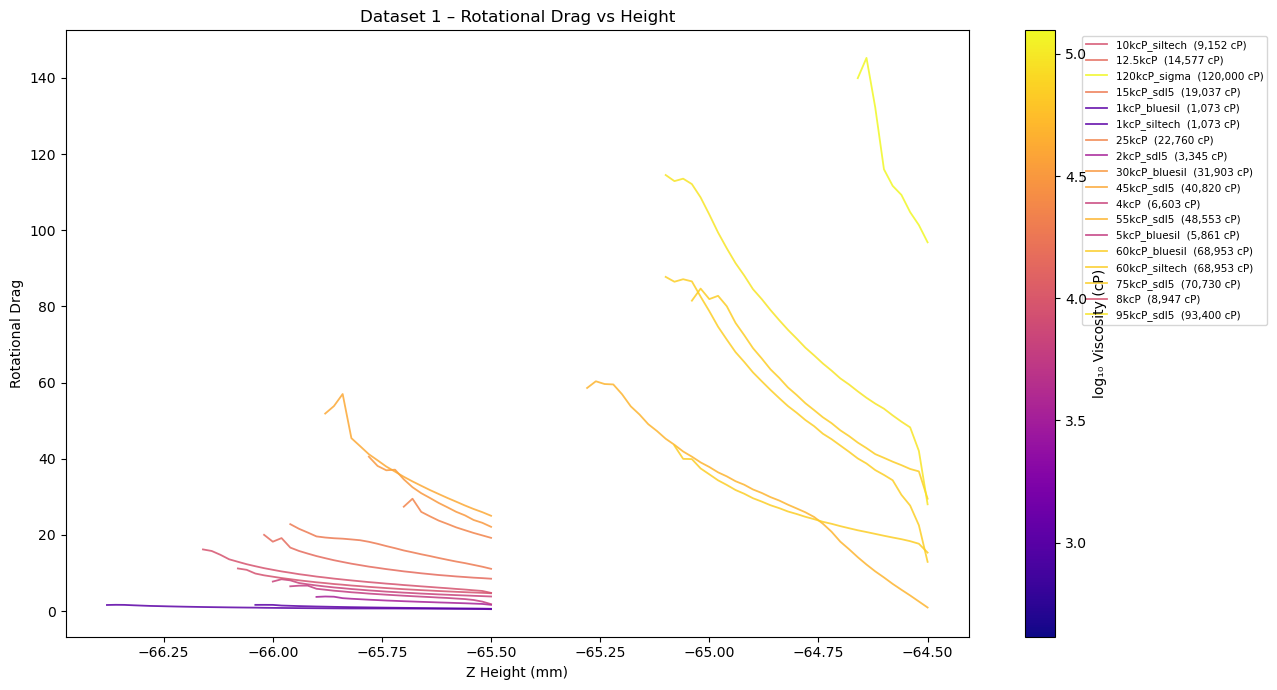

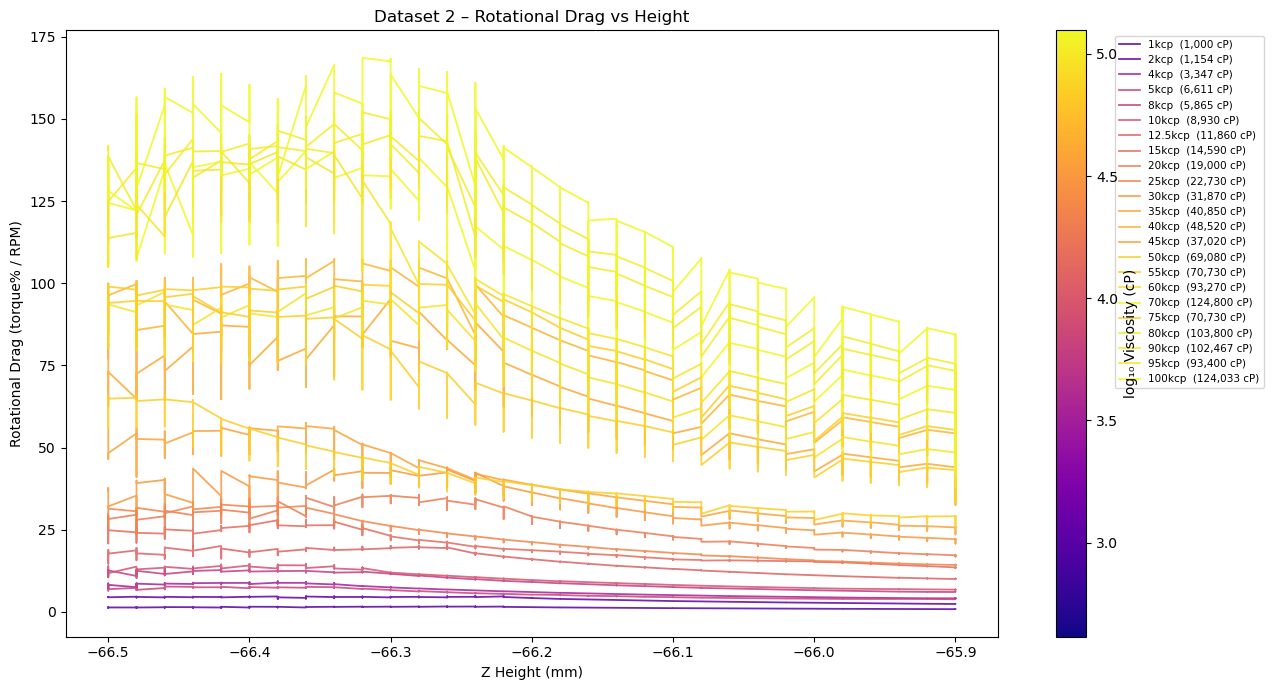

In [6]:
import re
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# viscosity_mapping alias required by extract_viscosity
viscosity_mapping = viscosity_mapping1

def extract_viscosity(viscosity_sample):
    """
    Standardized function to extract viscosity values from sample names.
    Uses the viscosity_mapping dictionary for consistent values across all cells.

    Parameters:
    viscosity_sample: str, sample name like "100kcp_t/rpm" or "100kcp"

    Returns:
    float: viscosity value in cP
    """
    # Remove '_t/rpm' suffix if present
    viscosity_label_str = viscosity_sample.replace('_t/rpm', '')
    # Normalize case: kcP -> kcp, cP -> cp
    viscosity_label_str = viscosity_label_str.replace('kcP', 'kcp').replace('cP', 'cp')
    # Remove vendor/source suffix (e.g. _bluesil, _siltech, _sdl5, _sigma)
    viscosity_label_str = re.sub(r'_[a-zA-Z0-9]+$', '', viscosity_label_str)

    # Use the mapping dictionary for consistent values
    if viscosity_label_str in viscosity_mapping:
        return viscosity_mapping[viscosity_label_str]

    # Fallback to old parsing method if not in mapping
    if 'kcp' in viscosity_label_str:
        return float(viscosity_label_str.replace('kcp', '')) * 1000
    else:
        return float(viscosity_label_str.replace('cp', ''))

# ── shared log-scale colormap across both datasets ─────────────────────────
_all_visc = list(viscosity_mapping1.values()) + list(real_viscosity_map2.values())
_log_min = np.log10(min(_all_visc))
_log_max = np.log10(max(_all_visc))
_plasma = plt.get_cmap('plasma')
_norm = mcolors.Normalize(vmin=_log_min, vmax=_log_max)

def _visc_color(v):
    return _plasma(_norm(np.log10(v)))

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 1 – df1: Rotational Drag vs Z_Height_mm
# ══════════════════════════════════════════════════════════════════════════════
cell_labels = sorted(df1['Cell_Label'].dropna().unique())

fig1, ax1 = plt.subplots(figsize=(13, 7))
for label in cell_labels:
    subset = df1[df1['Cell_Label'] == label].sort_values('Z_Height_mm')
    try:
        visc = extract_viscosity(label)
        color = _visc_color(visc)
        legend_label = f'{label}  ({visc:,.0f} cP)'
    except Exception:
        color = 'gray'
        legend_label = label
    ax1.plot(subset['Z_Height_mm'], subset['Rotational_Drag'],
             color=color, linewidth=1.3, alpha=0.85, label=legend_label)

sm1 = plt.cm.ScalarMappable(cmap=_plasma, norm=_norm)
sm1.set_array([])
fig1.colorbar(sm1, ax=ax1, label='log₁₀ Viscosity (cP)')
ax1.set_xlabel('Z Height (mm)')
ax1.set_ylabel('Rotational Drag')
ax1.set_title('Dataset 1 – Rotational Drag vs Height')
ax1.legend(bbox_to_anchor=(1.12, 1), loc='upper left', fontsize=7.5)
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 2 – df2: Rotational Drag (torque% / RPM) vs Z-Height
# Column index (1-based) → real_viscosity_map2
# RPM is encoded in the column name after '_rpm_'
# Rotational drag = torque% / RPM
# ══════════════════════════════════════════════════════════════════════════════
visc_cols2 = [c for c in df2.columns if c not in ('Z-Height', 'Elapsed_Time_s')]

fig2, ax2 = plt.subplots(figsize=(13, 7))
for i, col in enumerate(visc_cols2):
    col_idx = i + 1                              # 1-based index → real_viscosity_map2 key
    kcp_label = col.split('_torque')[0]          # e.g. '4kcp'
    rpm = float(col.split('_rpm_')[-1])          # RPM encoded in column name

    # Real viscosity from map (indices 1-18); fall back to viscosity_mapping1 for the rest
    if col_idx in real_viscosity_map2:
        visc = real_viscosity_map2[col_idx]
    else:
        visc = viscosity_mapping1.get(kcp_label)

    subset = df2[['Z-Height', col]].dropna().sort_values('Z-Height')
    rotational_drag = subset[col] / rpm          # convert torque% → rotational drag

    if visc is not None:
        color = _visc_color(visc)
        legend_label = f'{kcp_label}  ({visc:,.0f} cP)'
    else:
        color = 'gray'
        legend_label = kcp_label
    ax2.plot(subset['Z-Height'], rotational_drag,
             color=color, linewidth=1.3, alpha=0.85, label=legend_label)

sm2 = plt.cm.ScalarMappable(cmap=_plasma, norm=_norm)
sm2.set_array([])
fig2.colorbar(sm2, ax=ax2, label='log₁₀ Viscosity (cP)')
ax2.set_xlabel('Z Height (mm)')
ax2.set_ylabel('Rotational Drag (torque% / RPM)')
ax2.set_title('Dataset 2 – Rotational Drag vs Height')
ax2.legend(bbox_to_anchor=(1.12, 1), loc='upper left', fontsize=7.5)
plt.tight_layout()
plt.show()


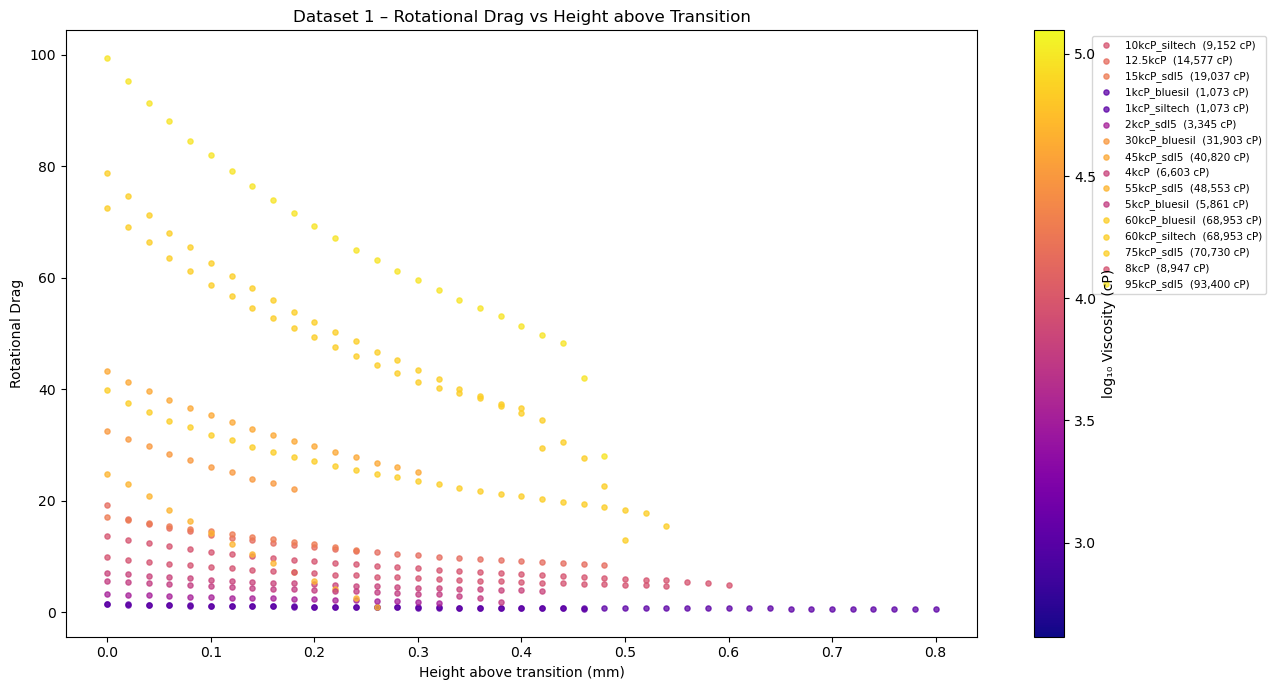

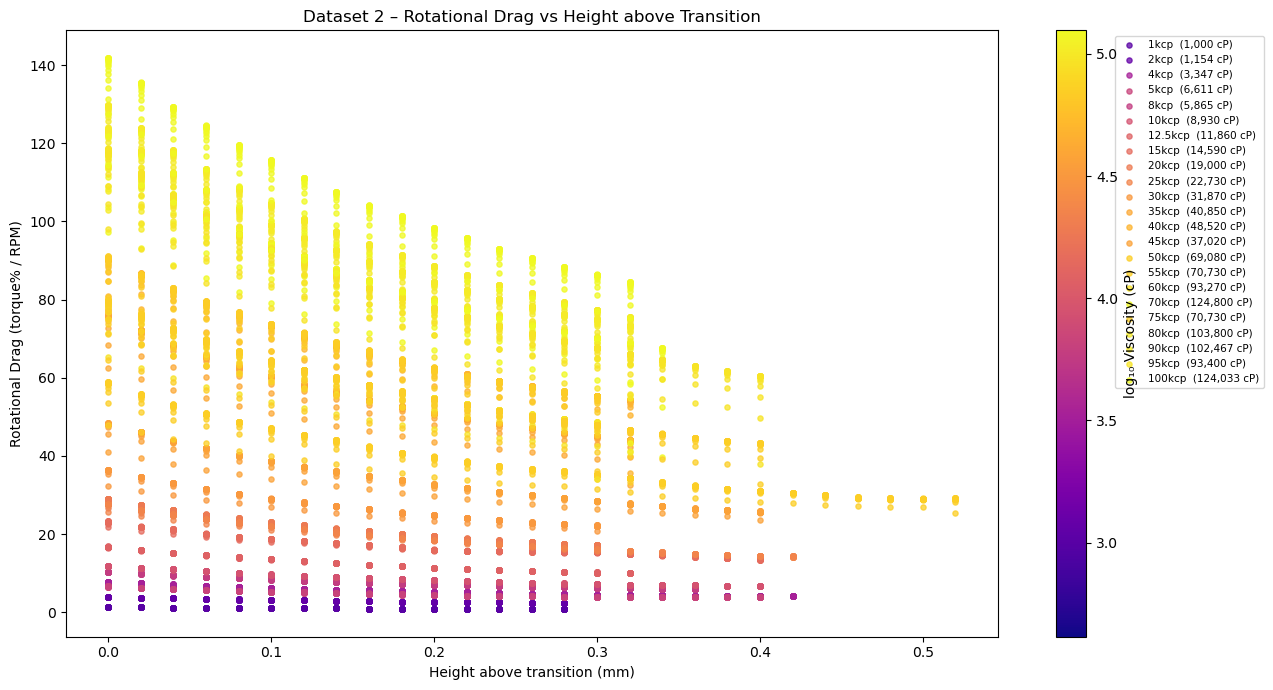

In [7]:
def find_transition_point(height_data, trpm_data, smoothing_window=5):
    """
    Find transition point where second derivative of T/RPM changes from positive to negative,
    starting from 75th percentile of highest heights and moving backward.
    """
    combined_data = list(zip(height_data, trpm_data))
    combined_data.sort(key=lambda x: x[0], reverse=True)

    heights = np.array([p[0] for p in combined_data])
    trpm_values = np.array([p[1] for p in combined_data])

    valid_mask = ~(np.isnan(heights) | np.isnan(trpm_values))
    heights = heights[valid_mask]
    trpm_values = trpm_values[valid_mask]

    if len(heights) < smoothing_window * 2:
        return None

    height_75th_percentile = np.percentile(heights, 75)
    start_mask = heights <= height_75th_percentile
    heights_filtered = heights[start_mask]
    trpm_filtered = trpm_values[start_mask]

    if len(heights_filtered) < smoothing_window * 2:
        return None

    if smoothing_window > 1:
        from scipy import ndimage
        trpm_smoothed = ndimage.uniform_filter1d(trpm_filtered, size=smoothing_window)
    else:
        trpm_smoothed = trpm_filtered

    first_derivative = np.gradient(trpm_smoothed, heights_filtered)
    second_derivative = np.gradient(first_derivative, heights_filtered)

    transition_idx = None
    for i in range(1, len(second_derivative)):
        if second_derivative[i - 1] > 0 and second_derivative[i] <= 0:
            transition_idx = i
            break

    return heights_filtered[transition_idx] if transition_idx is not None else None


# ══════════════════════════════════════════════════════════════════════════════
# Find transition heights – df1
# ══════════════════════════════════════════════════════════════════════════════
transitions1 = {}
for label in cell_labels:
    s = df1[df1['Cell_Label'] == label][['Z_Height_mm', 'Rotational_Drag']].dropna()
    transitions1[label] = find_transition_point(s['Z_Height_mm'].values, s['Rotational_Drag'].values)

# for k, v in transitions1.items():
#     print(f"  {k}: {v}")

# ══════════════════════════════════════════════════════════════════════════════
# Find transition heights – df2
# df2 has multiple time-point rows per unique Z-Height → aggregate to mean
# per height before gradient computation to avoid divide-by-zero in np.gradient
# ══════════════════════════════════════════════════════════════════════════════
transitions2 = {}
visc_map2 = {}   # col -> real viscosity (cP)
rpm_map2  = {}   # col -> RPM

for i, col in enumerate(visc_cols2):
    col_idx   = i + 1
    kcp_label = col.split('_torque')[0]
    rpm       = float(col.split('_rpm_')[-1])
    rpm_map2[col] = rpm
    visc_map2[col] = real_viscosity_map2[col_idx] if col_idx in real_viscosity_map2 \
                     else viscosity_mapping1.get(kcp_label)

    # Aggregate: mean rotational drag per unique height
    s = df2[['Z-Height', col]].dropna()
    agg = s.groupby('Z-Height')[col].mean().reset_index()
    agg_drag = (agg[col] / rpm).values
    transitions2[col] = find_transition_point(agg['Z-Height'].values, agg_drag)

# for k, v in transitions2.items():
#     #print(f"  {k.split('_torque')[0]}: {v}")


# ══════════════════════════════════════════════════════════════════════════════
# PLOT 3 – df1: Rotational Drag vs height above transition
# ══════════════════════════════════════════════════════════════════════════════
fig3, ax3 = plt.subplots(figsize=(13, 7))
for label in cell_labels:
    tp = transitions1[label]
    if tp is None:
        continue
    s = df1[df1['Cell_Label'] == label][['Z_Height_mm', 'Rotational_Drag']].dropna()
    above = s[s['Z_Height_mm'] >= tp].copy()
    above['height_above'] = above['Z_Height_mm'] - tp
    try:
        visc  = extract_viscosity(label)
        color = _visc_color(visc)
        lbl   = f'{label}  ({visc:,.0f} cP)'
    except Exception:
        color = 'gray'
        lbl   = label
    ax3.scatter(above['height_above'], above['Rotational_Drag'],
                color=color, s=14, alpha=0.75, label=lbl)

sm3 = plt.cm.ScalarMappable(cmap=_plasma, norm=_norm)
sm3.set_array([])
fig3.colorbar(sm3, ax=ax3, label='log₁₀ Viscosity (cP)')
ax3.set_xlabel('Height above transition (mm)')
ax3.set_ylabel('Rotational Drag')
ax3.set_title('Dataset 1 – Rotational Drag vs Height above Transition')
ax3.legend(bbox_to_anchor=(1.12, 1), loc='upper left', fontsize=7.5)
plt.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# PLOT 4 – df2: Rotational Drag vs height above transition
# Raw rows are kept for the scatter (shows time-series spread per height)
# ══════════════════════════════════════════════════════════════════════════════
fig4, ax4 = plt.subplots(figsize=(13, 7))
for col in visc_cols2:
    tp   = transitions2[col]
    if tp is None:
        continue
    rpm       = rpm_map2[col]
    visc      = visc_map2[col]
    kcp_label = col.split('_torque')[0]

    s = df2[['Z-Height', col]].dropna()
    s = s[s['Z-Height'] >= tp].copy()
    s['rot_drag']     = s[col] / rpm
    s['height_above'] = s['Z-Height'] - tp

    if visc is not None:
        color = _visc_color(visc)
        lbl   = f'{kcp_label}  ({visc:,.0f} cP)'
    else:
        color = 'gray'
        lbl   = kcp_label
    ax4.scatter(s['height_above'], s['rot_drag'],
                color=color, s=14, alpha=0.75, label=lbl)

sm4 = plt.cm.ScalarMappable(cmap=_plasma, norm=_norm)
sm4.set_array([])
fig4.colorbar(sm4, ax=ax4, label='log₁₀ Viscosity (cP)')
ax4.set_xlabel('Height above transition (mm)')
ax4.set_ylabel('Rotational Drag (torque% / RPM)')
ax4.set_title('Dataset 2 – Rotational Drag vs Height above Transition')
ax4.legend(bbox_to_anchor=(1.12, 1), loc='upper left', fontsize=7.5)
plt.tight_layout()
plt.show()


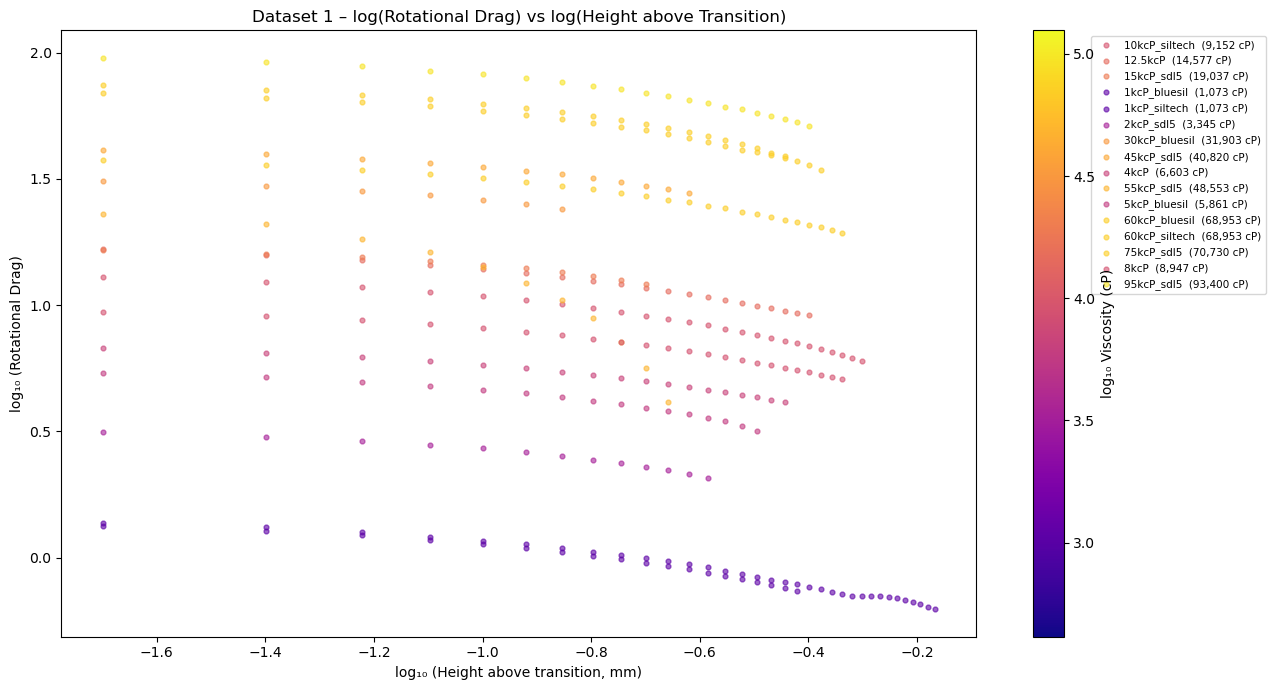

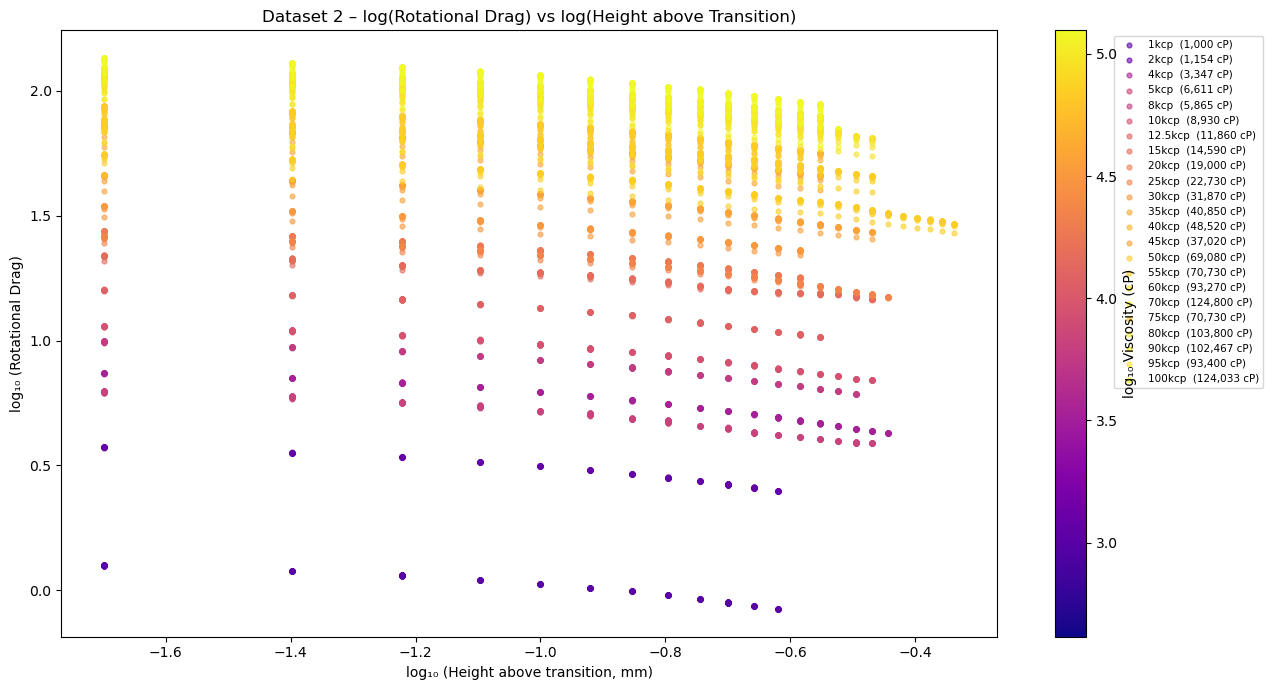

Sample                   slope   intercept    Measured (cP)    Actual (cP)
─────────────────────────────────────────────────────────────────────────
Dataset 1
─────────────────────────────────────────────────────────────────────────
  10kcP_siltech         -0.261      0.7481                6          9,152
  12.5kcP               -0.220      0.9003                8         14,577
  15kcP_sdl5            -0.133      1.0131               10         19,037
  1kcP_bluesil          -0.259     -0.2147                1          1,073
  1kcP_siltech          -0.217     -0.1886                1          1,073
  2kcP_sdl5             -0.164      0.2490                2          3,345
  30kcP_bluesil         -0.129      1.2845               19         31,903
  45kcP_sdl5            -0.162      1.3684               23         40,820
  4kcP                  -0.184      0.5603                4          6,603
  55kcP_sdl5            -0.667      0.3801                2         48,553
  5kcP_bluesil   

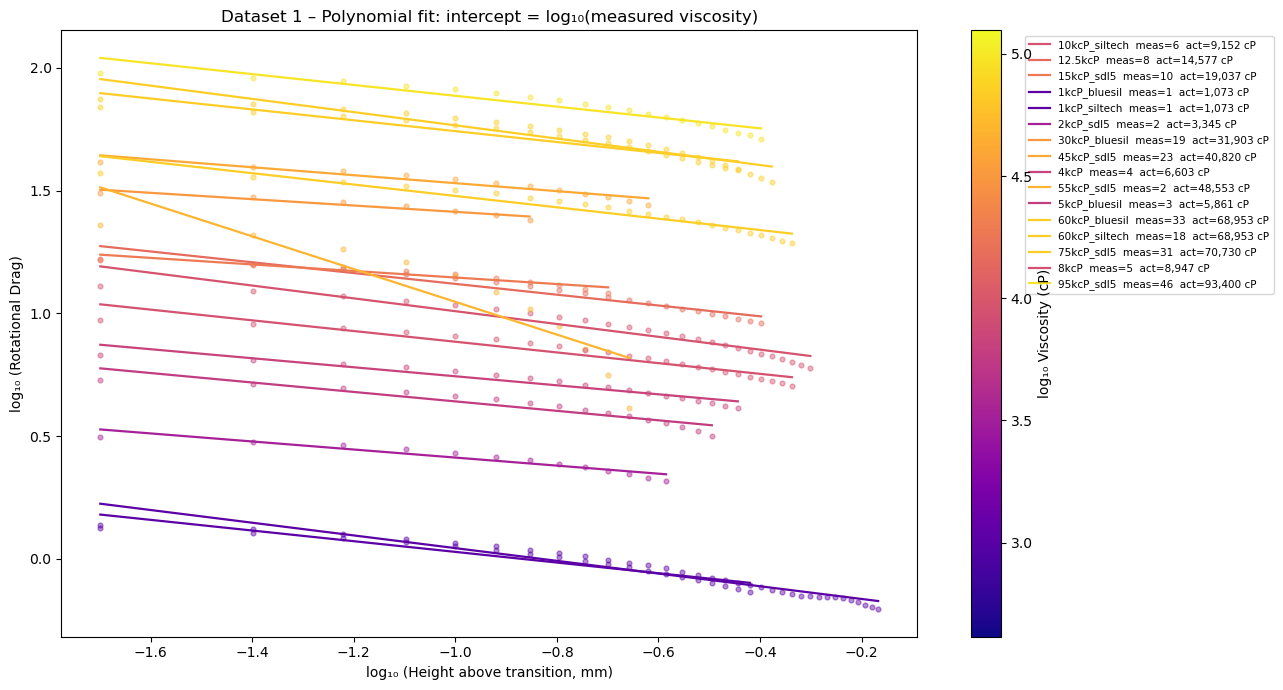


─────────────────────────────────────────────────────────────────────────
Dataset 2
─────────────────────────────────────────────────────────────────────────
  1kcp                  -0.166     -0.1563                1          1,000
  2kcp                  -0.167      0.3157                2          1,154
  4kcp                  -0.211      0.5609                4          3,347
  5kcp                  -0.188      0.5120                3          6,611
  8kcp                  -0.186      0.7173                5          5,865
  10kcp                 -0.193      0.7718                6          8,930
  12.5kcp               -0.174      0.9387                9         11,860
  15kcp                 -0.153      1.1055               13         14,590
  20kcp                 -0.174      1.1707               15         19,000
  25kcp                 -0.209      1.1101               13         22,730
  30kcp                 -0.166      1.2810               19         31,870
  35kcp         

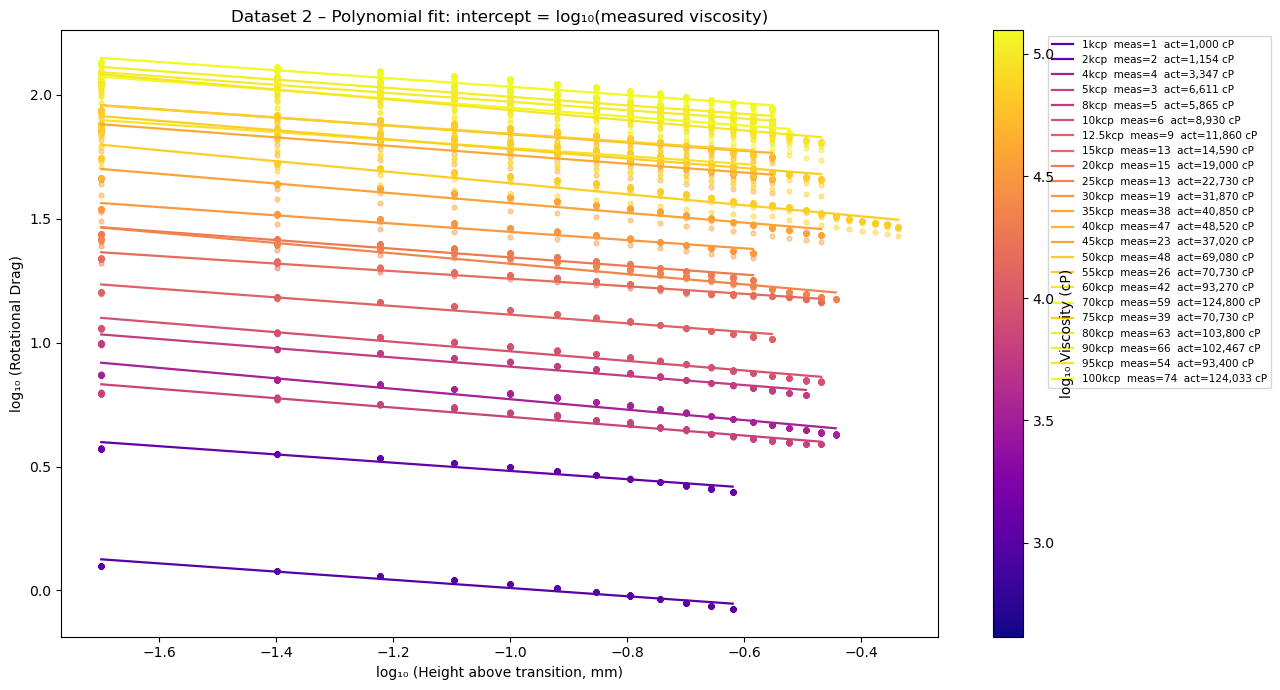

In [9]:
# ── helpers ────────────────────────────────────────────────────────────────

def _log_data_df1(label, tp):
    """log10(height_above), log10(rot_drag) for df1, bottom 85% of heights only."""
    s = df1[df1['Cell_Label'] == label][['Z_Height_mm', 'Rotational_Drag']].dropna()
    s = s[s['Z_Height_mm'] >= tp].copy()
    s['height_above'] = s['Z_Height_mm'] - tp
    s = s[(s['height_above'] > 0) & (s['Rotational_Drag'] > 0)]
    if len(s) < 3:
        return None, None
    p85 = np.percentile(s['height_above'], 85)
    s = s[s['height_above'] <= p85]
    if len(s) < 3:
        return None, None
    return np.log10(s['height_above'].values), np.log10(s['Rotational_Drag'].values)


def _log_data_df2(col, tp, rpm):
    """log10(height_above), log10(rot_drag) for df2, bottom 85% of heights only."""
    s = df2[['Z-Height', col]].dropna()
    s = s[s['Z-Height'] >= tp].copy()
    s['rot_drag']     = s[col] / rpm
    s['height_above'] = s['Z-Height'] - tp
    s = s[(s['height_above'] > 0) & (s['rot_drag'] > 0)]
    if len(s) < 3:
        return None, None
    p85 = np.percentile(s['height_above'], 85)
    s = s[s['height_above'] <= p85]
    if len(s) < 3:
        return None, None
    return np.log10(s['height_above'].values), np.log10(s['rot_drag'].values)


def _fit_poly1(log_h, log_drag):
    """
    Fit first-order polynomial: log(drag) = slope * log(height) + intercept
    Returns (slope, intercept).  intercept = log10(viscosity).
    """
    slope, intercept = np.polyfit(log_h, log_drag, 1)
    return float(slope), float(intercept)


fits1 = {}   # label -> (slope, intercept)
fits2 = {}   # col   -> (slope, intercept)

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 5 – df1: log(Rotational Drag) vs log(height above transition)
# ══════════════════════════════════════════════════════════════════════════════
fig5, ax5 = plt.subplots(figsize=(13, 7))

for label in cell_labels:
    tp = transitions1.get(label)
    if tp is None:
        continue
    log_h, log_d = _log_data_df1(label, tp)
    if log_h is None:
        continue
    try:
        visc  = extract_viscosity(label)
        color = _visc_color(visc)
        lbl   = f'{label}  ({visc:,.0f} cP)'
    except Exception:
        color = 'gray'
        lbl   = label
    ax5.scatter(log_h, log_d, color=color, s=12, alpha=0.6, label=lbl)
    fits1[label] = _fit_poly1(log_h, log_d)

sm5 = plt.cm.ScalarMappable(cmap=_plasma, norm=_norm)
sm5.set_array([])
fig5.colorbar(sm5, ax=ax5, label='log₁₀ Viscosity (cP)')
ax5.set_xlabel('log₁₀ (Height above transition, mm)')
ax5.set_ylabel('log₁₀ (Rotational Drag)')
ax5.set_title('Dataset 1 – log(Rotational Drag) vs log(Height above Transition)')
ax5.legend(bbox_to_anchor=(1.12, 1), loc='upper left', fontsize=7.5)
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 6 – df2: log(Rotational Drag) vs log(height above transition)
# fig6 is created AFTER fig5.show() to prevent it being rendered empty
# ══════════════════════════════════════════════════════════════════════════════
fig6, ax6 = plt.subplots(figsize=(13, 7))

for col in visc_cols2:
    tp = transitions2.get(col)
    if tp is None:
        continue
    rpm       = rpm_map2[col]
    visc      = visc_map2[col]
    kcp_label = col.split('_torque')[0]
    log_h, log_d = _log_data_df2(col, tp, rpm)
    if log_h is None:
        continue
    color = _visc_color(visc) if visc is not None else 'gray'
    lbl   = f'{kcp_label}  ({visc:,.0f} cP)' if visc is not None else kcp_label
    ax6.scatter(log_h, log_d, color=color, s=12, alpha=0.6, label=lbl)
    fits2[col] = _fit_poly1(log_h, log_d)

sm6 = plt.cm.ScalarMappable(cmap=_plasma, norm=_norm)
sm6.set_array([])
fig6.colorbar(sm6, ax=ax6, label='log₁₀ Viscosity (cP)')
ax6.set_xlabel('log₁₀ (Height above transition, mm)')
ax6.set_ylabel('log₁₀ (Rotational Drag)')
ax6.set_title('Dataset 2 – log(Rotational Drag) vs log(Height above Transition)')
ax6.legend(bbox_to_anchor=(1.12, 1), loc='upper left', fontsize=7.5)
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 7 – df1: data + polynomial fit, intercept → measured viscosity
# ══════════════════════════════════════════════════════════════════════════════
print(f"{'Sample':<22} {'slope':>7}  {'intercept':>10}  {'Measured (cP)':>15}  {'Actual (cP)':>13}")
print("─" * 73)
print("Dataset 1")
print("─" * 73)

fig7, ax7 = plt.subplots(figsize=(13, 7))
for label in cell_labels:
    tp = transitions1.get(label)
    if tp is None or label not in fits1:
        continue
    log_h, log_d = _log_data_df1(label, tp)
    if log_h is None:
        continue
    slope, intercept = fits1[label]
    measured_visc = 10 ** intercept
    try:
        actual_visc = extract_viscosity(label)
        color = _visc_color(actual_visc)
        lbl   = f'{label}  meas={measured_visc:,.0f}  act={actual_visc:,.0f} cP'
        print(f"  {label:<20} {slope:>7.3f}  {intercept:>10.4f}  {measured_visc:>15,.0f}  {actual_visc:>13,.0f}")
    except Exception:
        color = 'gray'
        lbl   = f'{label}  meas={measured_visc:,.0f} cP'
        print(f"  {label:<20} {slope:>7.3f}  {intercept:>10.4f}  {measured_visc:>15,.0f}  {'—':>13}")
    ax7.scatter(log_h, log_d, color=color, s=12, alpha=0.45)
    x_fit = np.linspace(log_h.min(), log_h.max(), 200)
    ax7.plot(x_fit, slope * x_fit + intercept, color=color, linewidth=1.6, label=lbl)

sm7 = plt.cm.ScalarMappable(cmap=_plasma, norm=_norm)
sm7.set_array([])
fig7.colorbar(sm7, ax=ax7, label='log₁₀ Viscosity (cP)')
ax7.set_xlabel('log₁₀ (Height above transition, mm)')
ax7.set_ylabel('log₁₀ (Rotational Drag)')
ax7.set_title('Dataset 1 – Polynomial fit: intercept = log₁₀(measured viscosity)')
ax7.legend(bbox_to_anchor=(1.12, 1), loc='upper left', fontsize=7.5)
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 8 – df2: data + polynomial fit, intercept → measured viscosity
# ══════════════════════════════════════════════════════════════════════════════
print()
print("─" * 73)
print("Dataset 2")
print("─" * 73)

fig8, ax8 = plt.subplots(figsize=(13, 7))
for col in visc_cols2:
    tp = transitions2.get(col)
    if tp is None or col not in fits2:
        continue
    rpm       = rpm_map2[col]
    visc      = visc_map2[col]
    kcp_label = col.split('_torque')[0]
    log_h, log_d = _log_data_df2(col, tp, rpm)
    if log_h is None:
        continue
    slope, intercept = fits2[col]
    measured_visc = 10 ** intercept
    color   = _visc_color(visc) if visc is not None else 'gray'
    act_str = f'{visc:,.0f}' if visc is not None else '—'
    lbl     = f'{kcp_label}  meas={measured_visc:,.0f}  act={act_str} cP'
    print(f"  {kcp_label:<20} {slope:>7.3f}  {intercept:>10.4f}  {measured_visc:>15,.0f}  {act_str:>13}")
    ax8.scatter(log_h, log_d, color=color, s=12, alpha=0.45)
    x_fit = np.linspace(log_h.min(), log_h.max(), 200)
    ax8.plot(x_fit, slope * x_fit + intercept, color=color, linewidth=1.6, label=lbl)

sm8 = plt.cm.ScalarMappable(cmap=_plasma, norm=_norm)
sm8.set_array([])
fig8.colorbar(sm8, ax=ax8, label='log₁₀ Viscosity (cP)')
ax8.set_xlabel('log₁₀ (Height above transition, mm)')
ax8.set_ylabel('log₁₀ (Rotational Drag)')
ax8.set_title('Dataset 2 – Polynomial fit: intercept = log₁₀(measured viscosity)')
ax8.legend(bbox_to_anchor=(1.12, 1), loc='upper left', fontsize=7.5)
plt.tight_layout()
plt.show()
